This notebook contains :
1.) Load data
2.) Take quick look (head, info, describe)
3.) Visualize distributions

In [30]:
print(f"lets start with first machine learning project")

lets start with first machine learning project


Task: Use California census data to build a model of housing prices in the state.

Objective: Model's output (a prediction to districts median housing price) will be essential to determine whether it is worth investing in a given area.
Our models output will be fed to another machine learning system for investment analysis.

## Problem Type

This is a supervised regression problem where the goal is to predict a continuous target variable (median_house_value).

In [31]:
import sys

assert sys.version_info >= (3, 10)

from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Step-1 Get the data


Welcome to Machine Learning Housing Corp.! 
Task is to predict median house values in Californian districts, given a number of features from these districts.

EDA = Understand your data BEFORE modeling so you don’t build garbage models

In [32]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

Whyyyyy?  housing_full.head()
To understand:
- What features exist
- What kind of data (numerical, categorical)
- What the target variable looks like

In [33]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Initial Data Inspection

The dataset contains housing-related features such as location, income, population, and median house value (target).

We observe both numerical and categorical features (e.g., ocean_proximity).

Why? housing_full.info():
To identify:
- Missing values
- Data types (int, float, object)
- Number of entries

In [34]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Data Structure

- Dataset has X entries and Y features
- `total_bedrooms` contains missing values → needs handling later
- `ocean_proximity` is categorical

In [35]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

To understand:
- Range of values
- Mean vs median (skew)
- Outliers (very high max values)

In [36]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Statistical Summary

- Some features show capped values (e.g., housing_median_age)
- Income is normalized rather than absolute
- Presence of potential outliers in population and households

To detect:
- Skewed data
- Normal vs non-normal distribution
- Feature scaling needs

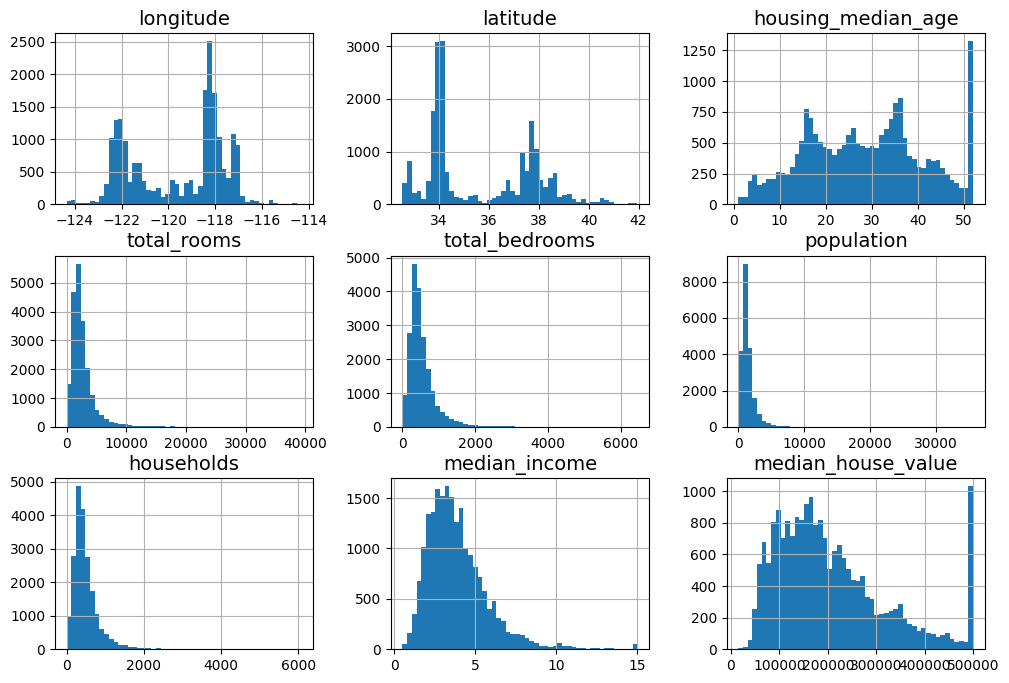

In [37]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

## Feature Distributions

- Many features are right-skewed (e.g., median_income)
- Target variable is capped → may affect model predictions
- Non-normal distributions suggest need for transformation later

## Impact on ML Pipeline

Based on EDA, the following preprocessing steps will be required:

- Missing Value Handling  
  `total_bedrooms` contains missing values → will require imputation

- Feature Scaling  
  Features like population and income have different ranges → scaling needed

- Handling Skewness  
  Right-skewed features may require transformation (e.g., log scaling)

- Categorical Encoding  
  `ocean_proximity` is categorical → will require encoding (OneHotEncoding)

- Target Value Limitation  
  Median house value is capped → may affect model performance and predictions

## Create Test Set

In [38]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [39]:
rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)
len(train_set)

16512

In [40]:
len(test_set)

4128

Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

Note: another source of randomness is the order of Python sets: it is based on Python's hash() function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the PYTHONHASHSEED environment variable to "0" before Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.




In [41]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [42]:
housing_with_id = housing_full.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [43]:
housing_with_id["id"] = (housing_full["longitude"] * 1000
                         + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [44]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

In [45]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

To find the probability that a random sample of 1,000 people contains less than 49% female or more than 54% female when the population's female ratio is 51.6%, we use the binomial distribution. The cdf() method of the binomial distribution gives us the probability that the number of females will be equal or less than the given value.

In [46]:
# extra code – shows how to compute the 10.7% proba of getting a bad sample

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.516
proba_too_small = binom(sample_size, ratio_female).cdf(490 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(540)
print(proba_too_small + proba_too_large)

0.10727422667455991


In [47]:
# If you prefer simulations over maths, here's how you could get roughly the same result:
# extra code – shows another way to estimate the probability of bad sample

rng = np.random.default_rng(seed=42)
samples = (rng.random((100_000, sample_size)) < ratio_female).sum(axis=1)
((samples < 490) | (samples > 540)).mean()

np.float64(0.1077)

## Why Not Simple Random Split?

A purely random train-test split may not preserve the distribution of important features like median income.

This can lead to:
- Biased training data
- Misleading model evaluation

To ensure the dataset is representative, we use stratified sampling based on income categories.

In [48]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

## Stratified Sampling Explanation

- Continuous feature `median_income` is converted into categorical bins using `pd.cut`
- This allows us to perform stratified sampling
- `StratifiedShuffleSplit` ensures that train and test sets maintain similar distributions
- This prevents bias and improves model evaluation reliability

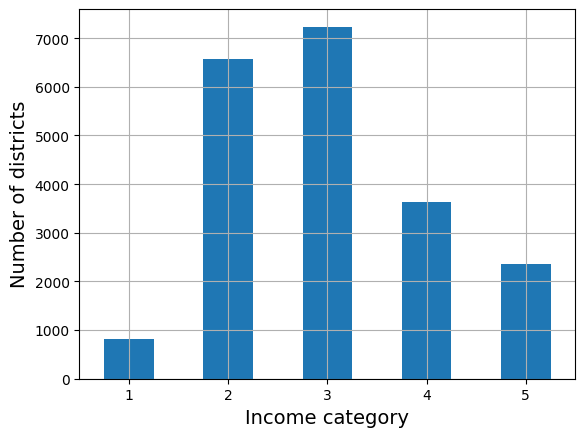

In [49]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

In [50]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full,
                                              housing_full["income_cat"]):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [51]:
strat_train_set, strat_test_set = strat_splits[0]

It's much shorter to get a single stratified split:

In [52]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, stratify=housing_full["income_cat"],
    random_state=42)

In [53]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [54]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_full),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


## Stratified vs Random Sampling Comparison

Stratified sampling preserves the distribution of income categories much better than random sampling.

This ensures that both training and test sets are representative of the overall dataset.

In [56]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts(normalize=True)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing_full),
    "Stratified": income_cat_proportions(strat_train_set),
    "Random": income_cat_proportions(train_set),
}).sort_index()

compare_props

,Overall,Stratified,Random
income_cat,,,
1,0.039826,0.039789,0.039184
2,0.318847,0.318859,0.321705
3,0.350581,0.350594,0.351926
4,0.176308,0.176296,0.174358
5,0.114438,0.114462,0.112827


In [28]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Removing Temporary Feature

The `income_cat` feature was created only for stratified sampling and is removed to avoid unintended influence on the model.

## Avoiding Data Leakage

After splitting the dataset, all further analysis and preprocessing is performed only on the training set.

This prevents information from the test set leaking into the model, ensuring unbiased evaluation.

## Discover and Visualize the Data to Gain Insights

In [57]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

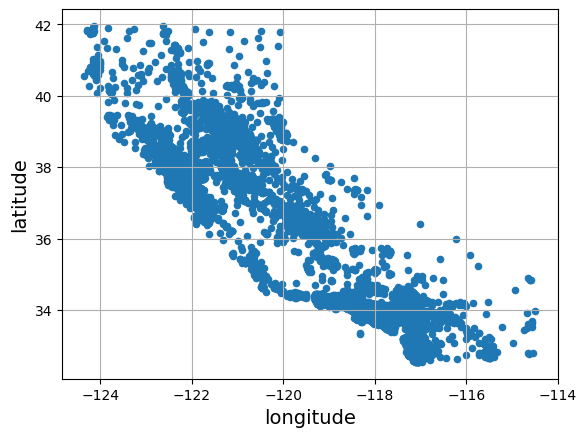

In [58]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)

plt.show()

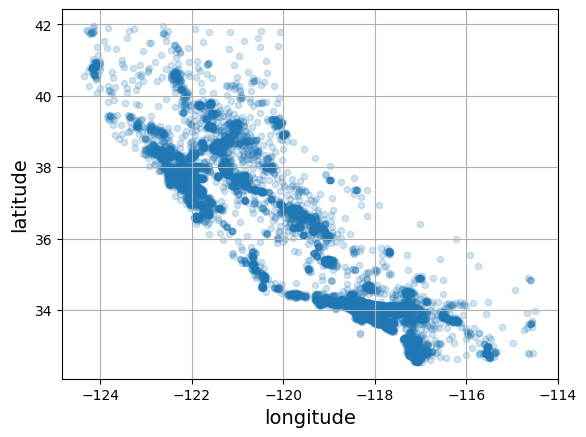

In [59]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)

plt.show()

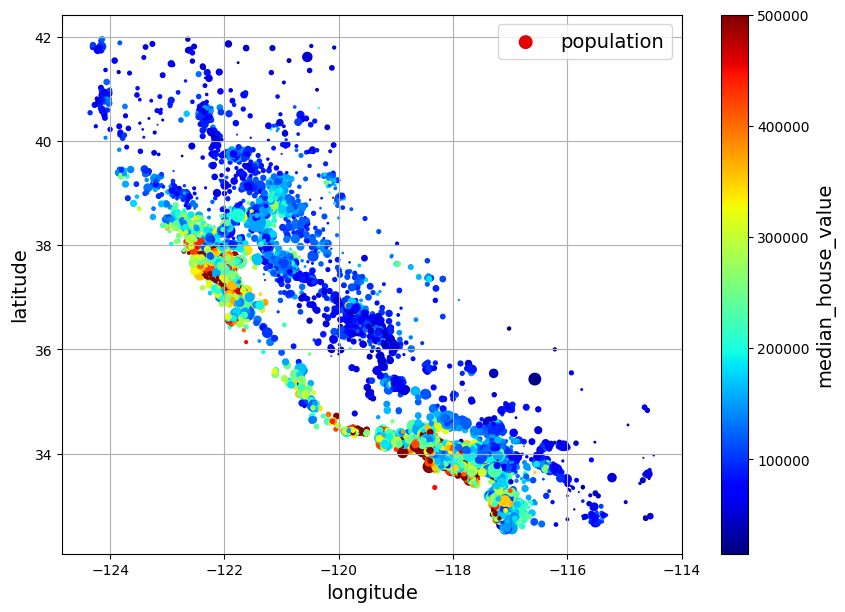

In [60]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=housing["population"] / 100, label="population",
            c="median_house_value", cmap="jet", colorbar=True,
            legend=True, sharex=False, figsize=(10, 7))

plt.show()

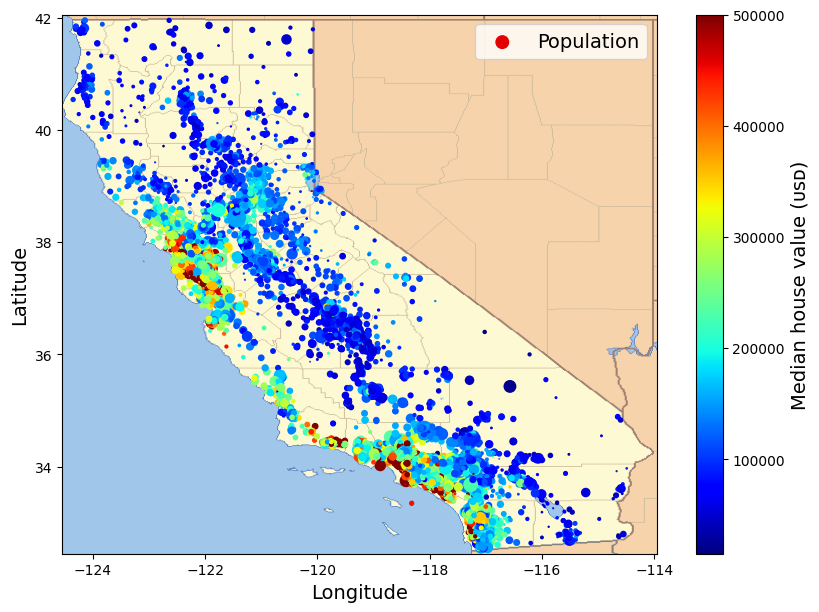

In [61]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
filename = "california.png"
filepath = Path(f"my_{filename}")
if not filepath.is_file():
    homlp_root = "https://github.com/ageron/handson-mlp/raw/main/"
    url = homlp_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, filepath)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(filepath)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.show()